In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [ ]:
df = pd.read_csv("../data/processed/ecommerce_logs.csv", parse_dates=["event_time"])

In [7]:
print(df.isnull().sum())   
print(df.duplicated().sum())
print(df.dtypes)          

user_id       0
product_id    0
event_time    0
event_type    0
dtype: int64
9
user_id               object
product_id            object
event_time    datetime64[ns]
event_type            object
dtype: object


In [8]:
print(f"Before: {len(df):,}행")
df = df.drop_duplicates()
print(f"After: {len(df):,}행")

Before: 10,000행
After: 9,991행


In [9]:
df.head()

,user_id,product_id,event_time,event_type
0,84f28ac55d936946d201442e1a1e9058,21c00997a28e1efcdd07c8a67f26d4ce,2018-03-25 13:53:34,click
1,394e76e6142e712aba5f104757d90984,4678fb24818cab9ec956d9b610435d9f,2018-05-14 09:26:53,click
2,d12c9220f616b02b0e58cdcd3fc1eea4,37ba623c5ab34ea8b964009a10e87126,2018-08-09 17:08:38,purchase
3,99c2f528e9be47ab3d3ea403c4bddf42,5411e9269501a870cabf632f05655131,2017-12-06 16:09:00,click
4,7e059909ea55e4548694d7da1ee6ab13,aa280035c50ba62c746480a59045eec4,2017-07-20 19:18:03,click


### 이벤트 타입 분포

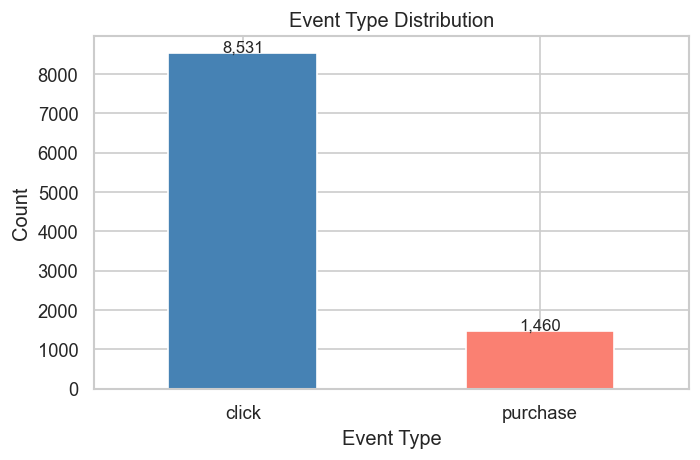

event_type
click       8531
purchase    1460
Name: count, dtype: int64

Overall CVR: 17.11%


In [15]:
event_counts = df['event_type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
event_counts.plot(kind='bar', color=['steelblue', 'salmon'], ax=ax, edgecolor='white')
ax.set_title('Event Type Distribution')
ax.set_xlabel('Event Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(event_counts):
    ax.text(i, v + 30, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(event_counts)
print(f'\nOverall CVR: {event_counts.get("purchase", 0) / event_counts.get("click", 1):.2%}')

### 유저 행동 피처 

In [16]:
user_stats = (
    df.groupby(['user_id', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'click': 'click_count', 'purchase': 'purchase_count'})
)

user_stats['conversion_rate'] = (
    user_stats['purchase_count']
    / user_stats['click_count'].replace(0, float('nan'))
).fillna(0)

user_stats['churn_flag'] = (
    (user_stats['click_count'] > 0) & (user_stats['purchase_count'] == 0)
).astype(int)

print(f'Total Users: {len(user_stats):,}')
user_stats.describe().round(3)

Total Users: 9,553


event_type,click_count,purchase_count,conversion_rate,churn_flag
count,9553.000,9553.000,9553.000,9553.000
mean,0.893,0.153,0.012,0.847
std,0.404,0.361,0.109,0.360
min,0.000,0.000,0.000,0.000
25%,1.000,0.000,0.000,1.000
50%,1.000,0.000,0.000,1.000
75%,1.000,0.000,0.000,1.000
max,3.000,2.000,1.000,1.000


### 유저별 클릭 / 구매 분포

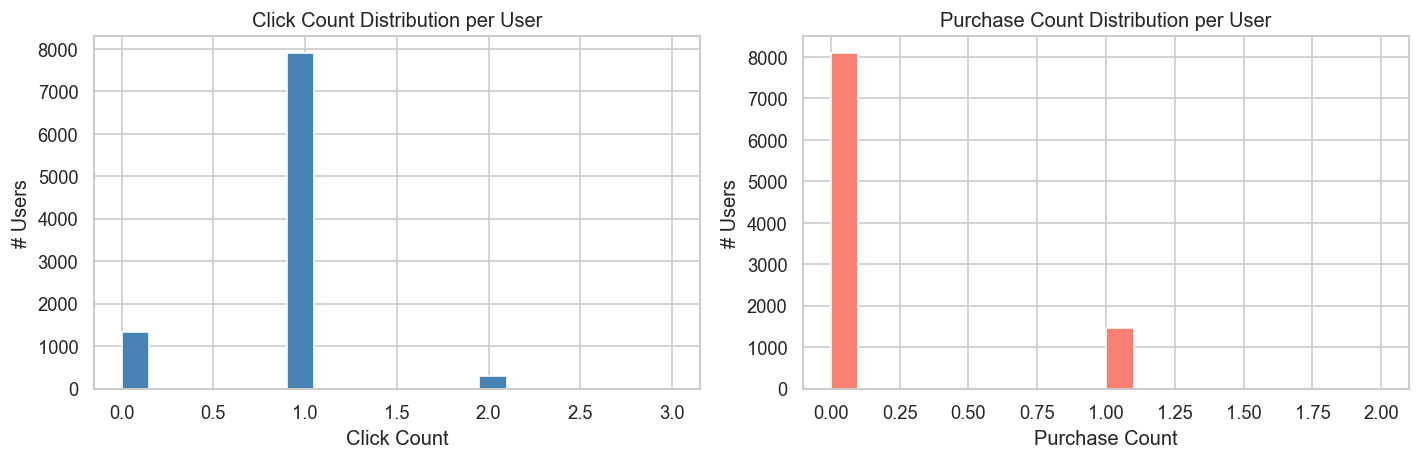

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(user_stats['click_count'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Click Count Distribution per User')
axes[0].set_xlabel('Click Count')
axes[0].set_ylabel('# Users')

axes[1].hist(user_stats['purchase_count'], bins=20, color='salmon', edgecolor='white')
axes[1].set_title('Purchase Count Distribution per User')
axes[1].set_xlabel('Purchase Count')
axes[1].set_ylabel('# Users')

plt.tight_layout()
plt.show()

### 전환율 분석

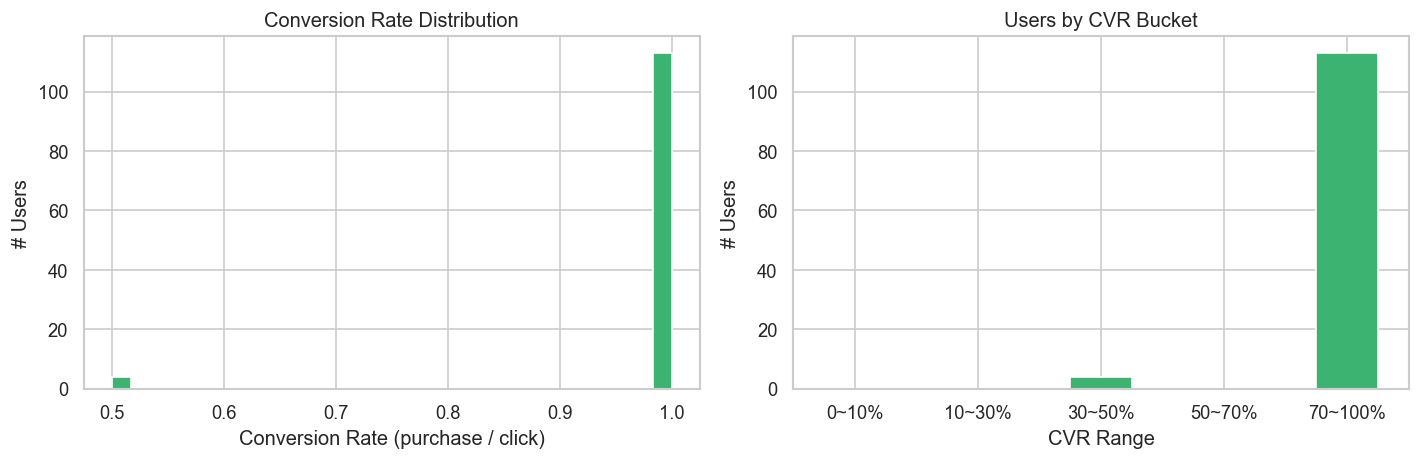

Mean CVR:   1.20%
Median CVR: 0.00%


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    user_stats['conversion_rate'].replace(0, float('nan')).dropna(),
    bins=30, color='mediumseagreen', edgecolor='white'
)
axes[0].set_title('Conversion Rate Distribution')
axes[0].set_xlabel('Conversion Rate (purchase / click)')
axes[0].set_ylabel('# Users')

bins   = [0, 0.1, 0.3, 0.5, 0.7, 1.01]
labels = ['0~10%', '10~30%', '30~50%', '50~70%', '70~100%']
user_stats['cvr_bucket'] = pd.cut(
    user_stats['conversion_rate'], bins=bins, labels=labels
)
user_stats['cvr_bucket'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white'
)
axes[1].set_title('Users by CVR Bucket')
axes[1].set_xlabel('CVR Range')
axes[1].set_ylabel('# Users')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'Mean CVR:   {user_stats["conversion_rate"].mean():.2%}')
print(f'Median CVR: {user_stats["conversion_rate"].median():.2%}')

### 이탈 유저 특징 분석

C:\Users\color\AppData\Local\Temp\ipykernel_26160\2723620912.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


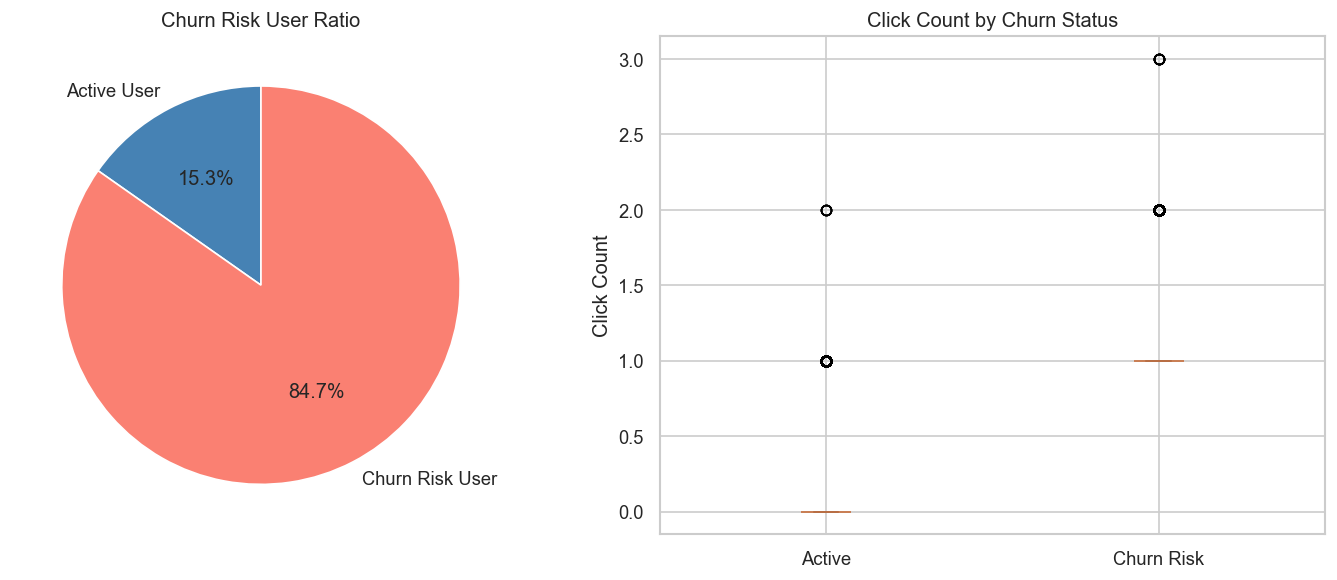

Churn Risk Users: 8,096 (84.7%)
Churn Avg Clicks: 1.0
Active Avg Clicks: 0.1


In [19]:
churn  = user_stats[user_stats['churn_flag'] == 1]
active = user_stats[user_stats['churn_flag'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    [len(active), len(churn)],
    labels=['Active User', 'Churn Risk User'],
    autopct='%1.1f%%',
    colors=['steelblue', 'salmon'],
    startangle=90
)
axes[0].set_title('Churn Risk User Ratio')

axes[1].boxplot(
    [active['click_count'], churn['click_count']],
    labels=['Active', 'Churn Risk'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[1].set_title('Click Count by Churn Status')
axes[1].set_ylabel('Click Count')

plt.tight_layout()
plt.show()

print(f'Churn Risk Users: {len(churn):,} ({len(churn)/len(user_stats):.1%})')
print(f'Churn Avg Clicks: {churn["click_count"].mean():.1f}')
print(f'Active Avg Clicks: {active["click_count"].mean():.1f}')

### 시간대 / 요일별 트렌드

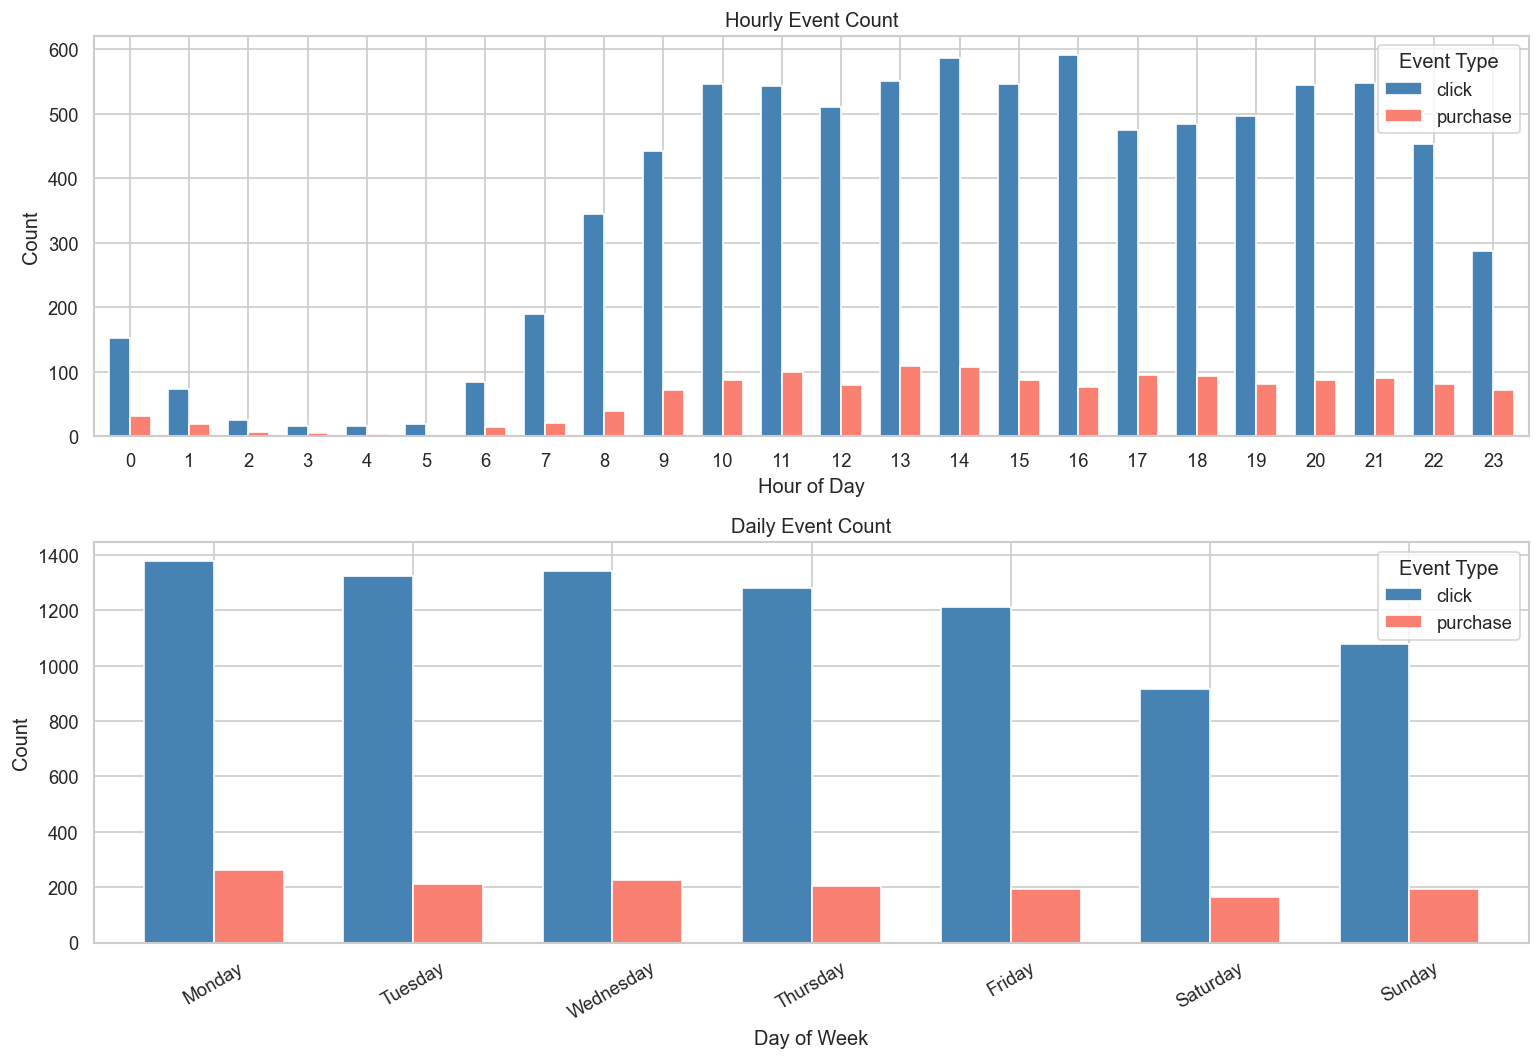

In [20]:
df['hour']      = df['event_time'].dt.hour
df['dayofweek'] = df['event_time'].dt.day_name()

hourly = df.groupby(['hour', 'event_type']).size().unstack(fill_value=0)

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = (
    df.groupby(['dayofweek', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(dow_order)
)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

hourly.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], width=0.7, edgecolor='white')
axes[0].set_title('Hourly Event Count')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Event Type')

dow.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7, edgecolor='white')
axes[1].set_title('Daily Event Count')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Event Type')

plt.tight_layout()
plt.show()

### 상품 인기도 분석

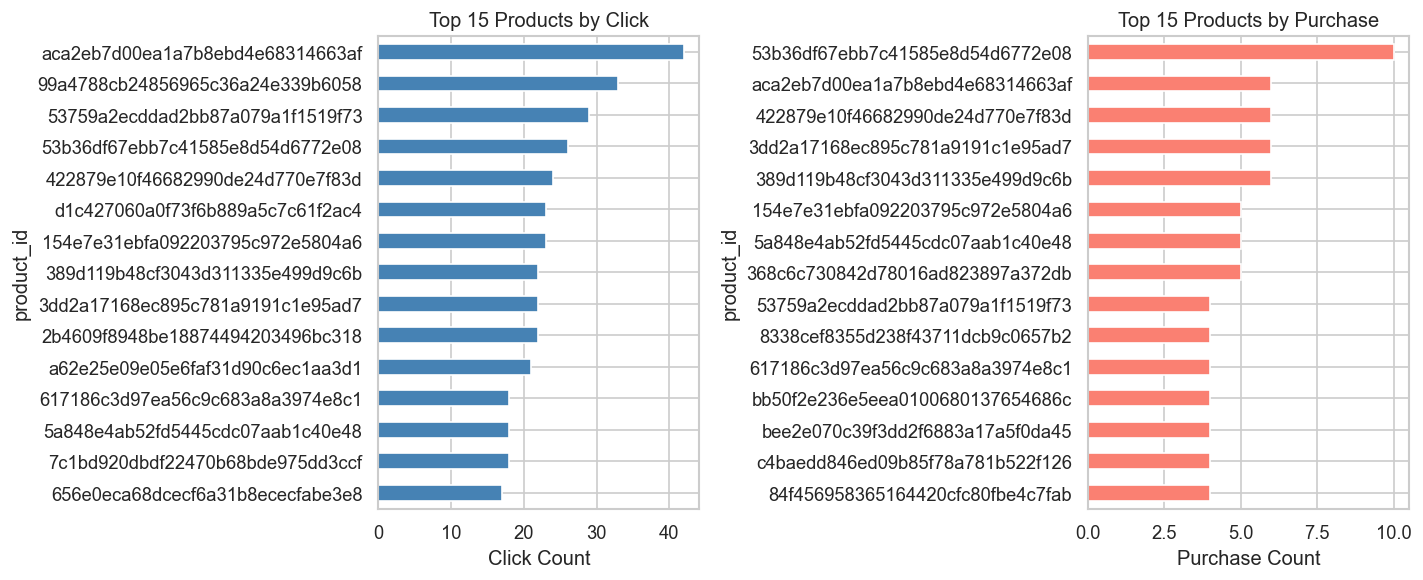

High Click / Zero Purchase Products: 70


In [21]:
product_stats = (
    df.groupby(['product_id', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'click': 'click_count', 'purchase': 'purchase_count'})
)

product_stats['conversion_rate'] = (
    product_stats['purchase_count']
    / product_stats['click_count'].replace(0, float('nan'))
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

product_stats['click_count'].nlargest(15).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Top 15 Products by Click')
axes[0].set_xlabel('Click Count')

product_stats['purchase_count'].nlargest(15).sort_values().plot(
    kind='barh', ax=axes[1], color='salmon', edgecolor='white'
)
axes[1].set_title('Top 15 Products by Purchase')
axes[1].set_xlabel('Purchase Count')

plt.tight_layout()
plt.show()

dead_products = product_stats[
    (product_stats['click_count'] >= 5) & (product_stats['purchase_count'] == 0)
]
print(f'High Click / Zero Purchase Products: {len(dead_products):,}')